In [1]:
# Dependencias y configuración reproducible
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models



I0000 00:00:1791390453.846746  382502 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Carga y visualización del dataset


In [2]:
# Cargar las imagenes del dataset
ruta = "data/images/"

imagenes = []
# teniendo la ruta de las imagenes, cargamos y preprocesamos las imagenes
for i in range(30000):  
    img = Image.open(ruta+str(i)+".jpg").resize((64, 64))
    img_array = np.array(img)
    img_array = img_array / 255.0


    imagenes.append(img_array)

print("Número de imágenes cargadas:", len(imagenes))
print("Dimensiones de las imágenes:", imagenes[0].shape)


Número de imágenes cargadas: 30000
Dimensiones de las imágenes: (64, 64, 3)


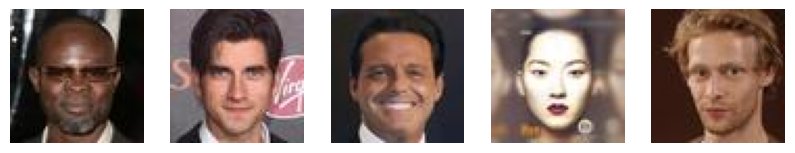

In [3]:
# mostramos algunas imágenes del dataset
plt.figure(figsize=(10, 10))



for i in range(5):
    n = random.randint(0, len(imagenes) - 1)
    plt.subplot(1, 5, i + 1)
    plt.imshow(imagenes[n])
    plt.axis('off')

plt.show()

In [ ]:
# Convertir la lista a un array 4D
# El uso de float32 reduce el consumo de memoria RAM a la mitad
X_train = np.array(imagenes, dtype=np.float32)
print("Formato final para el modelo:", X_train.shape) # Debería ser (30000, 64, 64, 3)


---

## 2. Arquitectura AE 

### CREACIÓN DEL AE

In [4]:
LATENT_DIM = 128

# ENCODER 
encoder_inputs = layers.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=1, padding="same")(encoder_inputs)
x = layers.MaxPooling2D(pool_size=2, strides=2, padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", strides=1, padding="same")(x)
x = layers.MaxPooling2D(pool_size=2, strides=2, padding="same")(x)
x = layers.Flatten()(x)
latent_output = layers.Dense(LATENT_DIM)(x)

encoder = models.Model(encoder_inputs, latent_output, name="encoder")

# DECODER 
decoder_inputs = layers.Input(shape=(LATENT_DIM,))
# Adaptar la dimensión para poder hacer el Reshape (ej. 16x16x64 = 16384)
x = layers.Dense(16 * 16 * 64, activation="relu")(decoder_inputs)
x = layers.Reshape((16, 16, 64))(x)
x = layers.UpSampling2D(size=2)(x) # Sube a 32x32
x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(size=2)(x) # Sube a 64x64
x = layers.Conv2DTranspose(32, 3, activation="relu", padding="same")(x)
# La última capa convolucional ya se aplica sobre el 64x64 y saca los 3 canales de color (RGB)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = models.Model(decoder_inputs, decoder_outputs, name="decoder")


# AUTOENCODER COMPLETO
ae_inputs = layers.Input(shape=(64, 64, 3))
ae_outputs = decoder(encoder(ae_inputs))
autoencoder = models.Model(ae_inputs, ae_outputs, name="autoencoder")

# Compilación y entrenamiento
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

I0000 00:00:1791390475.479353  382502 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5792 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │     2,116,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │     2,169,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,286,467 (16.35 MB)

 Trainable params: 4,286,467 (16.35 MB)

 Non-trainable params: 0 (0.00 B)

### ENTRENAMIENTO DE LA AE

In [ ]:

# Iniciar el entrenamiento
history = autoencoder.fit(
    x=X_train, 
    y=X_train, 
    epochs=5,            # Ajusta este valor si las caras están muy borrosas
    batch_size=128,       # Cantidad de imágenes que procesa la GPU a la vez
    shuffle=True,         # Evita que el modelo memorice el orden del dataset
    validation_split=0.1  # Reserva 3000 imágenes para evaluar el error real
)

Formato final para el modelo: (30000, 64, 64, 3)


W0000 00:00:1791390487.925976  382502 cpu_allocator_impl.cc:82] Allocation of 1327104000 exceeds 10% of free system memory.
W0000 00:00:1791390491.622844  382502 cpu_allocator_impl.cc:82] Allocation of 1327104000 exceeds 10% of free system memory.
W0000 00:00:1791390493.583854  382502 cpu_allocator_impl.cc:82] Allocation of 1327104000 exceeds 10% of free system memory.
W0000 00:00:1791390494.840136  382502 cpu_allocator_impl.cc:82] Allocation of 1327104000 exceeds 10% of free system memory.


Epoch 1/5


I0000 00:00:1791390500.268509  382783 service.cc:153] XLA service 0x7f251d23e320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791390500.268859  382783 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1791390500.476846  382783 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791390501.105899  382783 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1791390501.151724  382783 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2924__.30
I0000 00:00:1791390510.165259  383002 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8456 bytes spill stores, 8496 bytes spill loads

I0000 00:00:1791390513.379450  383004 subprocess_compilation.cc:34

  5/211 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0822  

I0000 00:00:1791390519.221145  382783 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0258

I0000 00:00:1791390526.145643  382781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2924__.30
I0000 00:00:1791390528.452391  383540 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8712 bytes spill stores, 8708 bytes spill loads

I0000 00:00:1791390535.896627  383545 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8484 bytes spill stores, 8608 bytes spill loads



211/211 ━━━━━━━━━━━━━━━━━━━━ 52s 138ms/step - loss: 0.0257 - val_loss: 0.0134
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0102 - val_loss: 0.0090
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0081 - val_loss: 0.0075
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0070 - val_loss: 0.0069
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0065 - val_loss: 0.0066


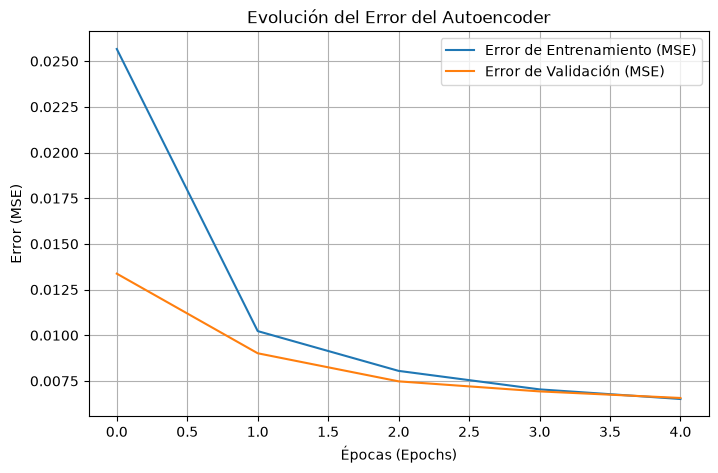

In [6]:
import matplotlib.pyplot as plt

# Extraer los datos del historial de entrenamiento
loss = history.history['loss']
val_loss = history.history['val_loss']

# Pintar la gráfica
plt.figure(figsize=(8, 5))
plt.plot(loss, label='Error de Entrenamiento (MSE)')
plt.plot(val_loss, label='Error de Validación (MSE)')
plt.title('Evolución del Error del Autoencoder')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### RESULTADOS DEL AE

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


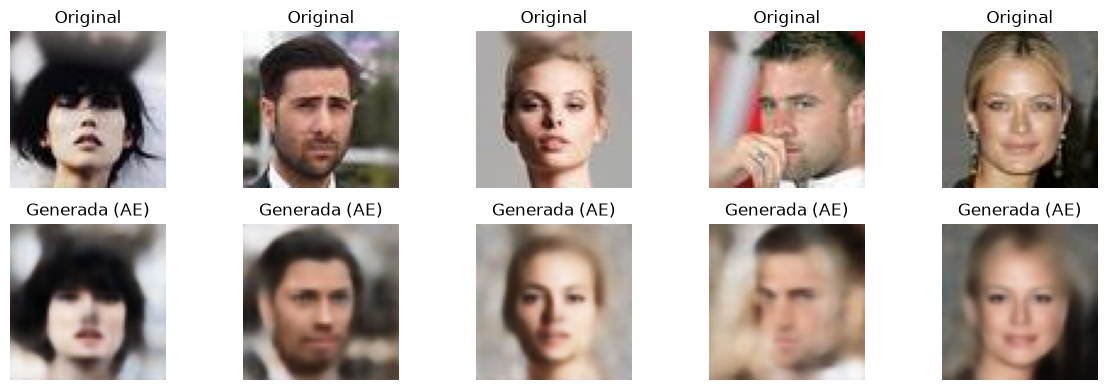

In [7]:
import numpy as np

# 1. Seleccionar 5 imágenes aleatorias de tu dataset
num_imagenes = 5
indices_aleatorios = np.random.randint(0, len(X_train), num_imagenes)
imagenes_reales = X_train[indices_aleatorios]

# 2. Pasar las imágenes por el modelo para que intente reconstruirlas
imagenes_reconstruidas = autoencoder.predict(imagenes_reales)

# 3. Pintar las imágenes
plt.figure(figsize=(12, 4))
for i in range(num_imagenes):
    # Fila superior: Imágenes originales
    ax = plt.subplot(2, num_imagenes, i + 1)
    plt.imshow(imagenes_reales[i])
    plt.title("Original")
    plt.axis("off")
    
    # Fila inferior: Imágenes generadas por tu Autoencoder
    ax = plt.subplot(2, num_imagenes, i + 1 + num_imagenes)
    plt.imshow(imagenes_reconstruidas[i])
    plt.title("Generada (AE)")
    plt.axis("off")

plt.tight_layout()
plt.show()

---

# 3. Arquitectura VAE

### CREACIÓN DE LA VAE

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K

# (Asumimos que ya tienes definidos LATENT_DIM y encoder_inputs, x, etc. como antes)
LATENT_DIM = 128
IMG_SHAPE = (64, 64, 3)

# --- 1. ENCODER ---
encoder_inputs = layers.Input(shape=IMG_SHAPE, name='encoder_input')

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], LATENT_DIM))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z_sampling")([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


# --- 2. DECODER ---
latent_inputs = layers.Input(shape=(LATENT_DIM,), name='decoder_input')

x = layers.Dense(16 * 16 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((16, 16, 64))(x)

x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")


# --- 3. UNIR TODO EN EL MODELO VAE (CORRECCIÓN AQUÍ) ---

# Pasamos la entrada por el Encoder
z_mean_out, z_log_var_out, z_out = encoder(encoder_inputs)

# Pasamos el vector 'z' por el Decoder
vae_outputs = decoder(z_out)

# Creamos una Capa Personalizada para calcular y añadir la pérdida KL
class KLLossLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        # El cálculo matemático ahora está seguro dentro del método 'call' de una capa
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        kl_loss = tf.reduce_mean(kl_loss) # Media sobre el batch
        
        # Escalamos la pérdida (como antes) para que compita con el MSE de 64x64x3
        self.add_loss(kl_loss / (64.0 * 64.0 * 3.0))
        return z_mean # No importa lo que devuelva, lo importante es el add_loss

# Instanciamos y aplicamos la capa a nuestras variables
_ = KLLossLayer()([z_mean_out, z_log_var_out])

# Creamos el modelo VAE final
vae = models.Model(encoder_inputs, vae_outputs, name="vae_funcional")

# Compilamos usando MSE como pérdida de reconstrucción
vae.compile(optimizer='adam', loss='mse')
vae.summary()

Model: "vae_funcional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ [(None, 128), (None,   │     4,279,744 │
│                                 │ 128), (None, 128)]     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │     2,169,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,449,539 (24.60 MB)

 Trainable params: 6,449,539 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento de la VAE

In [14]:
history_vae = vae.fit(
    x=X_train,
    y=X_train,
    epochs=5,            # Ajusta este valor si las caras están muy borrosas
    batch_size=128,       # Cantidad de imágenes que procesa la GPU a la vez
    shuffle=True,         # Evita que el modelo memorice el orden del dataset
    validation_split=0.1  # Reserva 3000 imágenes para evaluar el error real
)

W0000 00:00:1791391267.154022  382502 cpu_allocator_impl.cc:82] Allocation of 1327104000 exceeds 10% of free system memory.


Epoch 1/5


I0000 00:00:1791391296.826323  382784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12605__.12
I0000 00:00:1791391297.751494  391604 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1791391298.604669  391606 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 712 bytes spill stores, 712 bytes spill loads

I0000 00:00:1791391301.322892  391607 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 8460 bytes spill stores, 8500 bytes spill loads

I0000 00:00:1791391306.312342  382784 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using t

209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0354

I0000 00:00:1791391318.515834  382780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12605__.12
I0000 00:00:1791391321.439030  392041 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 8724 bytes spill stores, 8720 bytes spill loads

I0000 00:00:1791391321.472144  382780 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1791391327.116954  382780 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1791391332.928541  392039 subprocess_compilation.cc:348] ptxas warning : Registers are sp

211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0353

I0000 00:00:1791391345.705295  382784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13614__.3
I0000 00:00:1791391348.673865  382781 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13614__.3


211/211 ━━━━━━━━━━━━━━━━━━━━ 64s 194ms/step - loss: 0.0353 - val_loss: 0.0183
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0151 - val_loss: 0.0131
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0122 - val_loss: 0.0112
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0107 - val_loss: 0.0103
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0099 - val_loss: 0.0098


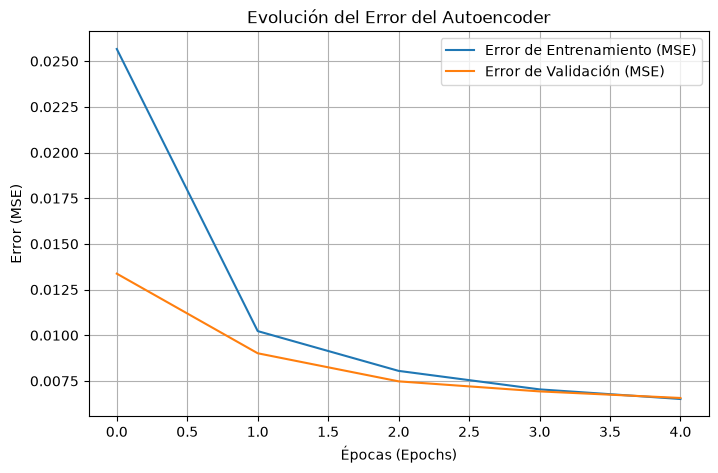

In [15]:
import matplotlib.pyplot as plt

# Extraer los datos del historial de entrenamiento
loss = history.history['loss']
val_loss = history.history['val_loss']

# Pintar la gráfica
plt.figure(figsize=(8, 5))
plt.plot(loss, label='Error de Entrenamiento (MSE)')
plt.plot(val_loss, label='Error de Validación (MSE)')
plt.title('Evolución del Error del Autoencoder')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### RESULTADOS DE LA VAE

I0000 00:00:1791391381.616817  382783 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16772__.1


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


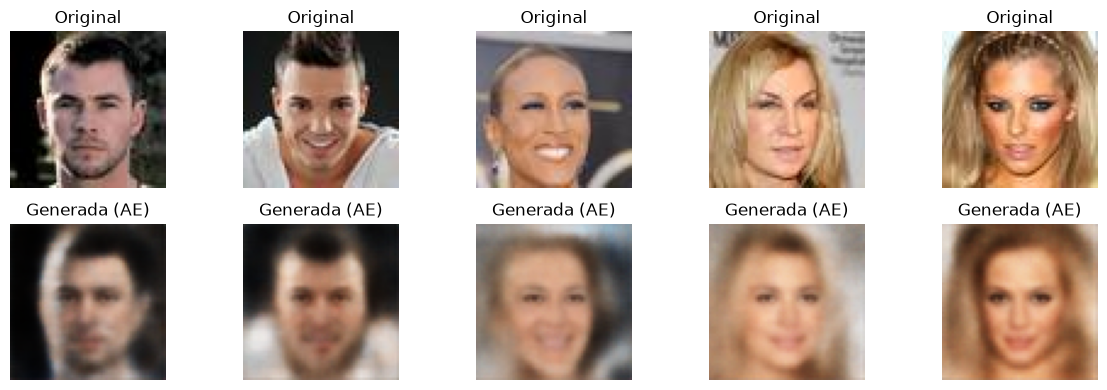

In [16]:
import numpy as np

# 1. Seleccionar 5 imágenes aleatorias de tu dataset
num_imagenes = 5
indices_aleatorios = np.random.randint(0, len(X_train), num_imagenes)
imagenes_reales = X_train[indices_aleatorios]

# 2. Pasar las imágenes por el modelo para que intente reconstruirlas
imagenes_reconstruidas = vae.predict(imagenes_reales)

# 3. Pintar las imágenes
plt.figure(figsize=(12, 4))
for i in range(num_imagenes):
    # Fila superior: Imágenes originales
    ax = plt.subplot(2, num_imagenes, i + 1)
    plt.imshow(imagenes_reales[i])
    plt.title("Original")
    plt.axis("off")
    
    # Fila inferior: Imágenes generadas por tu Autoencoder
    ax = plt.subplot(2, num_imagenes, i + 1 + num_imagenes)
    plt.imshow(imagenes_reconstruidas[i])
    plt.title("Generada (AE)")
    plt.axis("off")

plt.tight_layout()
plt.show()